Ask any football fan and they'd tell you the only thing worse than your club's manager getting sacked are the eight-to-ten matchweeks before it. A sacking is after all just the punctuation mark to a sustained period of on-pitch failure (barring the occasional club politics flare-up). If you love football and are chronically-online like me, you'd know that when your team is bad, a site like X becomes a literal doom-scroll; the in-fighting among fans, the crucifixion of players, AND worst of all, the glee of your rivals.

Fast forward 48 hours after the sacking: A new face shows up for the first press conference, says some nice things about the squad, and suddenly the same players who looked like they forgot how to pass a ball start playing with something resembling effort. Results pick up. The mood shifts. Fans who were writing eulogies two weeks ago are now talking about a top-four push.

People online call this the 'new manager bounce,' and it's one of those football concepts that's always fascinated and amused me. For the downtrodden fan, your hopes for the season are never over! Just switch out the manager and voila! Season saved. For the rival fan, a fresh face at the dugout means losing points. Like the hot hand fallacy in basketball, the new manager bounce is one of those things that everyone accepts as true without really questioning it. I'd never actually checked, but *it always felt true*. Today, however, as a fun exercise I wanted to see if the data actually backs it up. **Do teams genuinely perform better under a new manager, or are we just watching a bad streak naturally correct itself?** Upon inspection, this inquiry is causal in nature. So for this project I shall employ the techniques of **Causal Inference**! Before diving straight in, let's run through what Causal Inference is.

## Association is not causation… till it is!

This section shall be a quick primer on causal inference (a lot of this is taken from Matheus Facure Alves's excellent book, [Causal Inference for the Brave and True](https://matheusfacure.github.io/python-causality-handbook/landing-page.html)).

**Causal Inference** is a set of techniques for figuring out if an action or event is the cause of a specific outcome. It is great for answering questions like:

- What would happen if I used another price instead of this price I'm currently asking for my merchandise?
- What would happen if I do a low sugar one instead of this low-fat diet I'm on?
- Or more pertinently: **what would happen if I sack the manager instead of keeping him on?**

I think most people intuitively understand that association is not causation. Just because you noticed a correlation between two variables doesn't mean one variable caused the change in the other. However, distinguishing a correlation from causation isn't always straightforward. Like most things in life, what we perceive/observe is only a small part of what's actually happening.The fundamental task then of causal inference is figuring out whether the **association you observe is causation**.

So let's bring it back to football. A new manager come in to save a struggling team's season and instantly results improve (the association). But is the new manager the cause? From a fan's perspective it sure does seem like it. The fact that this phenomenon is perceived enough for it to have a name must mean something! The thing is, teams don't sack managers at random. They sack them when things are at their worst. And when you're at your worst, results tend to improve on their own. If your team loses five matches in a row, the most likely outcome is that the next few matches go a little better, regardless of who's in the dugout (we'd call this **regression to the mean**). So the question really becomes: **would results have improved just as much if the club had stuck with the old manager?**

To try to answer that, I'll be doing the following:

1. **Describe the bounce.** First, I want to see if the bounce even shows up in the raw data. I'll plot points per game in the six matches before a mid-season sacking and the five matches after. If the bounce is real, we should see a dip leading into the sacking and a jump right after.
2. **Build a fair comparison.** To isolate the effect of the sacking, we need to find clubs that looked just as bad at the same point in the season but kept their manager. Same league, similar table position, similar recent form. These are the "what if they hadn't sacked him" clubs. The matching method I'll use is called coarsened exact matching (CEM). I'll go into more detail later in this post.
3. **Estimate the effect.** Once we have our matched groups, we can estimate the ATT (average treatment effect on the treated). Let $T$ be whether a club sacked their manager ($T=1$) or kept them ($T=0$), $Y(1)$ be points per game after sacking, and $Y(0)$ be points per game after keeping:

$$\text{ATT} = E[Y(1) - Y(0) \mid T = 1]$$

In other words: among clubs that fired their manager, what's the difference between the points they actually got and the points they would have got if they'd kept the old manager? We never actually observe $Y(0)$, so matching will serve as our proxy.

For this estimate to mean anything, a few things have to be true:

- **Consistency.** I'm defining sackings as mid-season dismissals. So no resignations, mutual terminations, or end-of-contract departures.
- **Positivity.** For every club that sacked their manager, there need to be similar clubs that didn't.
- **Conditional exchangeability.** Given the variables we match on, the decision to sack has to be as good as random. The board can't be firing based on something important that we failed to account for.


## The data

For this project I need two things: (1) records on manager changes (who, when, how), and (2) Top-5 European league match results.

Match results come from [football-data.co.uk](https://www.football-data.co.uk), the usual open CSVs for the Big Five (Premier League, La Liga, Serie A, Bundesliga, Ligue 1). I stack them into a club-match panel: every team, every league game, with points (3/1/0), a running matchweek count, league position, and trailing form (points per game and goal difference over the last six matches). That panel goes back to 1993/94.

Managerial changes come mainly from Wikipedia's season pages, specifically the "Managerial changes" tables. With the help of Grok 4.6 and Composer 2.5, I scraped and parsed these into a CSV that contains who left, how they left (sacked, resigned, mutual consent), vacancy date, and who came in. Club names get mapped onto the football-data names so the two sources join. Where a season has no Wikipedia table, Transfermarkt filled the gaps. The managerial changes data covers 2004/05 through 2024/25, which is the window where the sacking data is usable.

After filtering to mid-season sackings with at least five league games remaining, the primary sample is **585 sacking events** across the Big Five leagues.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

panel = pd.read_parquet("data/intermediate/matches_panel.parquet")
events = pd.read_csv("data/processed/events.csv")
coded = pd.read_csv("data/processed/manager_changes_coded.csv")

panel = panel.sort_values(["league", "season", "club", "date"]).reset_index(drop=True)
panel["row_id"] = np.arange(len(panel))
wiki_seasons = set(events["season"].unique())
panel = panel[panel["season"].isin(wiki_seasons)].copy()

print(
    f"Panel: {len(panel):,} club-matches | seasons {min(wiki_seasons)}–{max(wiki_seasons)}"
)
print(f"Primary sackings: {int(events['in_primary_sample'].sum()):,}")


Panel: 75,720 club-matches | seasons 2004/05–2024/25
Primary sackings: 585


## Measuring the bounce

For each sacking, I mark $t=0$ as the last league match before the vacancy. The dependent variable is points per game over the next five league matches after that point. I chose five because it's long enough to smooth out a single lucky result but short enough that you're still measuring the early effect of the new manager, not his entire tenure. I also checked it separately outside of this notebook: five matches saw the *least* contamination. By match eight, about 13% of sacked clubs have had another managerial change, compared to about 8% by match five. The ATT comes out near zero at three, five, and eight matches anyway, but five is the cleanest primary window (three and eight are robustness checks).

The control units for this exercise are other club-matches in the same seasons that **look like a possible sacking moment but aren't**. So there's no managerial change (sacking, resignation, caretaker ending, etc.) in a window of six matchweeks before and five after, at least six games of trailing form, and five matches remaining.


In [25]:
g = panel.groupby(["league", "season", "club"], sort=False)
for k in range(1, 9):
    panel[f"lead_pts_{k}"] = g["points"].shift(-k)


def add_ppg_window(n: int) -> None:
    cols = [f"lead_pts_{k}" for k in range(1, n + 1)]
    ok = panel[cols].notna().all(axis=1)
    panel[f"has_next_{n}"] = ok
    panel[f"ppg_next_{n}"] = panel[cols].mean(axis=1).where(ok)


for n in (3, 5, 8):
    add_ppg_window(n)

treated_ev = events.query("in_primary_sample == True").copy()
treated_ev["date_vacancy"] = pd.to_datetime(treated_ev["date_vacancy"])
treated_ev["event_id"] = np.arange(len(treated_ev))

merged = panel.merge(
    treated_ev[["event_id", "league", "season", "panel_club", "date_vacancy"]],
    left_on=["league", "season", "club"],
    right_on=["league", "season", "panel_club"],
    how="inner",
)
t0 = (
    merged.loc[merged["date"] <= merged["date_vacancy"]]
    .sort_values("date")
    .groupby("event_id")
    .tail(1)
    .copy()
)
t0["treated"] = 1

ch = coded.loc[
    coded["club_matched"]
    & coded["in_season_window"]
    & coded["panel_club"].fillna("").ne("")
    & coded["season"].isin(wiki_seasons)
].copy()
ch["date_vacancy"] = pd.to_datetime(ch["date_vacancy_parsed"], errors="coerce")
ch = ch[ch["date_vacancy"].notna()]

ch_m = panel.merge(
    ch[["league", "season", "panel_club", "date_vacancy"]],
    left_on=["league", "season", "club"],
    right_on=["league", "season", "panel_club"],
    how="inner",
)
change_t0 = (
    ch_m.loc[ch_m["date"] <= ch_m["date_vacancy"]]
    .sort_values("date")
    .groupby(["league", "season", "club", "date_vacancy"], sort=False)
    .tail(1)[["league", "season", "club", "matchweek"]]
    .rename(columns={"matchweek": "change_mw"})
)

near = panel.merge(change_t0, on=["league", "season", "club"], how="left")
near["near_change"] = (
    near["change_mw"].notna()
    & (near["matchweek"] >= near["change_mw"] - 6)
    & (near["matchweek"] <= near["change_mw"] + 5)
)
near_ids = set(near.loc[near["near_change"], "row_id"])
treated_ids = set(t0["row_id"])

ctrl = panel.loc[
    ~panel["row_id"].isin(treated_ids)
    & ~panel["row_id"].isin(near_ids)
    & panel["has_next_5"]
    & (panel["trailing_matches"] >= 6)
    & (panel["matchweek"] > 1)
].copy()
ctrl["treated"] = 0

print(f"Treated (sacking t=0): {len(t0):,}")
print(f"Control candidates:     {len(ctrl):,}")


Treated (sacking t=0): 585
Control candidates:     46,770


## A first look at the data

### Sackings by league

Primary-sample mid-season sackings, 2004/05–2024/25. Check where your favorite league stands:


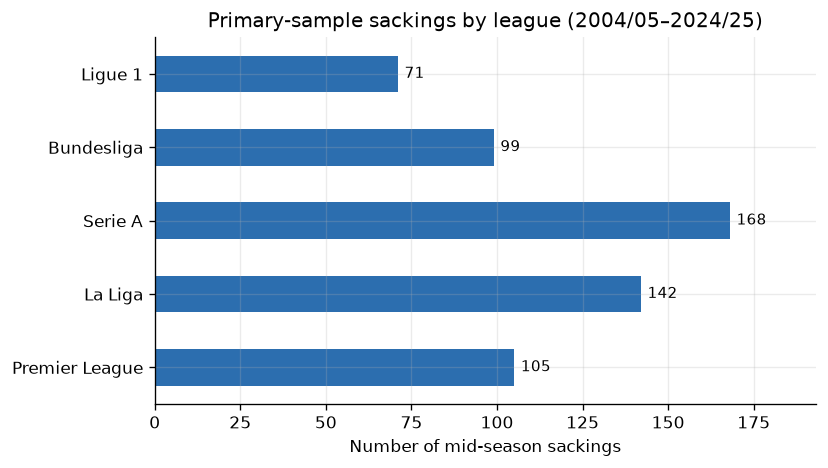

,sackings
league,
Premier League,105
La Liga,142
Serie A,168
Bundesliga,99
Ligue 1,71


In [26]:
league_labels = {
    "premier_league": "Premier League",
    "la_liga": "La Liga",
    "serie_a": "Serie A",
    "bundesliga": "Bundesliga",
    "ligue_1": "Ligue 1",
}

by_league = (
    t0["league"]
    .map(league_labels)
    .value_counts()
    .reindex(list(league_labels.values()))
)

fig, ax = plt.subplots(figsize=(7, 4))
by_league.plot(kind="barh", ax=ax, color="#2c6eaf")
ax.set_xlabel("Number of mid-season sackings")
ax.set_ylabel("")
ax.set_title("Primary-sample sackings by league (2004/05–2024/25)")
for i, v in enumerate(by_league):
    ax.text(v + 2, i, str(int(v)), va="center", fontsize=9)
ax.set_xlim(0, by_league.max() * 1.15)
plt.tight_layout()
plt.show()

by_league.rename("sackings").to_frame()


### The naive comparison

As a baseline, let's compare sacked clubs to all unsacked club-matches:


In [27]:
naive = pd.DataFrame(
    {
        "N": [len(t0), len(ctrl)],
        "PPG before (trailing 6)": [
            t0["trailing_6_ppg"].mean(),
            ctrl["trailing_6_ppg"].mean(),
        ],
        "PPG after (next 5)": [
            t0["ppg_next_5"].mean(),
            ctrl["ppg_next_5"].mean(),
        ],
    },
    index=["Sacked", "All valid unsacked matches"],
)
naive["Change"] = naive["PPG after (next 5)"] - naive["PPG before (trailing 6)"]
naive.round(3)


,N,PPG before (trailing 6),PPG after (next 5),Change
Sacked,585,0.663,1.211,0.547
All valid unsacked matches,46770,1.451,1.433,-0.019


As you can see, sacked clubs improve by over half a point per game! Looks like the bounce is real, right? But look at the "before" column. Sacked clubs were averaging 0.66 PPG, which is relegation form. Unsacked clubs were averaging 1.45. These groups aren't comparable. The improvement after the sacking could just be terrible form regressing to the mean.

This is the **bias** in the naive comparison. When you compute the simple difference in outcomes between sacked and unsacked clubs, you're actually getting two things mixed together: the real effect of the sacking (the ATT) plus the bias from comparing fundamentally different clubs. We can write this as:

$$\text{Simple difference} = \text{ATT} + \text{Bias}$$

The whole point of matching is to kill that bias term. If we can find unsacked clubs that were just as bad at the same point in the season, then any remaining difference in outcomes is closer to the true effect of the sacking.


## Coarsened exact matching

So to find teams that were as bad as the teams we'll be using a technique called Coarsened exact matching (CEM). CEM is quite simple. It works by **grouping similar observations together**. For each variable we're matching on (league, table position, recent form, goal difference), we split the range into a few bins. For example, table position might get split into top (1-6), mid (7-14), and bottom (15-20). Once every variable has been binned, we combine them to create groups. A group might be something like 'bottom-table team in the Premier League, mid-season, with poor recent form and a bad goal difference.' Every sacking and every candidate stayer falls into one of these groups based on their covariate values. If a group has at least one sacking and at least one stayer, we have a valid comparison. If a group only has sackings or only has stayers, there's no one to compare against, so it gets dropped. What survives is a set of sackings and stayers that looked similar enough on every variable to be placed in the same group.

I coarsen as follows:

| Covariate | Bins |
|---|---|
| League | Exact (Premier League is not "like" Serie A) |
| Matchweek | Early / mid / late (1–12, 13–24, 25+) |
| League position | Top / mid / bottom (1–6, 7–14, 15+) |
| Trailing 6 PPG | Fixed bands on the 0–3 scale, denser in the bad-form region where sackings live |
| Trailing 6 GD | Very bad / bad / slightly negative / positive / good |

Each sacking counts as 1. Controls in a bin are down-weighted so they sum to the number of sackings in that bin. That's the ATT: we care about clubs that *did* sack, and we reconstruct their $Y(0)$ from stayers who looked like them.


In [28]:
def add_bins(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["mw_bin"] = pd.cut(
        out["matchweek"], bins=[0, 12, 24, 40], labels=["early", "mid", "late"]
    )
    out["pos_bin"] = pd.cut(
        out["league_position"], bins=[0, 6, 14, 25], labels=["top", "mid", "bottom"]
    )
    out["form_bin"] = pd.cut(
        out["trailing_6_ppg"],
        bins=[-0.01, 0.5, 0.75, 1.0, 1.25, 1.5, 3.01],
        labels=["0-0.5", "0.5-0.75", "0.75-1", "1-1.25", "1.25-1.5", "1.5+"],
    )
    out["gd_bin"] = pd.cut(
        out["trailing_6_gd"],
        bins=[-99, -8, -4, 0, 4, 99],
        labels=["vbad", "bad", "neg", "pos", "good"],
    )
    out["stratum"] = (
        out[["league", "mw_bin", "pos_bin", "form_bin", "gd_bin"]]
        .astype(str)
        .agg("|".join, axis=1)
    )
    return out


def smd(x: pd.Series, t: pd.Series, w: pd.Series) -> float:
    mu1 = x[t == 1].mean()
    mu0 = (x[t == 0] * w[t == 0]).sum() / w[t == 0].sum()
    return (mu1 - mu0) / x.std(ddof=1)


pool = pd.concat([add_bins(t0), add_bins(ctrl)], ignore_index=True)
counts = pool.groupby("stratum")["treated"].agg(n_t="sum", n="size")
counts["n_c"] = counts["n"] - counts["n_t"]
keep = counts.query("n_t >= 1 and n_c >= 1").index
matched = pool.loc[pool["stratum"].isin(keep)].copy()

n_t = matched.groupby("stratum")["treated"].transform("sum")
n_c = matched.groupby("stratum")["treated"].transform(lambda s: (1 - s).sum())
matched["w"] = 1.0
matched.loc[matched["treated"] == 0, "w"] = (
    n_t[matched["treated"] == 0] / n_c[matched["treated"] == 0]
)

n_sacked = int(matched["treated"].sum())
n_stay = int((matched["treated"] == 0).sum())
print(f"Matched sackings: {n_sacked:,} of {len(t0):,}")
print(f"Matched stayers:  {n_stay:,}")
print(f"Strata used:      {matched.loc[matched.treated == 1, 'stratum'].nunique():,}")


Matched sackings: 581 of 585
Matched stayers:  19,015
Strata used:      236


### Did matching work?

Let's look at the standardized mean differences (SMD) before vs after matching.


In [29]:
covs = [
    ("matchweek", "Matchweek"),
    ("league_position", "League position"),
    ("trailing_6_ppg", "Trailing 6 PPG"),
    ("trailing_6_gd", "Trailing 6 GD"),
]

raw = pd.concat([t0.assign(w=1.0), ctrl.assign(w=1.0)], ignore_index=True)
balance = pd.DataFrame(
    {
        "SMD (raw)": [smd(raw[c], raw["treated"], raw["w"]) for c, _ in covs],
        "SMD (matched)": [
            smd(matched[c], matched["treated"], matched["w"]) for c, _ in covs
        ],
        "Mean sacked": [matched.loc[matched.treated == 1, c].mean() for c, _ in covs],
        "Mean stay (weighted)": [
            (
                matched.loc[matched.treated == 0, c]
                * matched.loc[matched.treated == 0, "w"]
            ).sum()
            / matched.loc[matched.treated == 0, "w"].sum()
            for c, _ in covs
        ],
    },
    index=[label for _, label in covs],
)
balance.round(3)


,SMD (raw),SMD (matched),Mean sacked,Mean stay (weighted)
Matchweek,-0.218,-0.064,17.448,17.934
League position,1.138,0.039,15.435,15.211
Trailing 6 PPG,-1.275,-0.049,0.661,0.693
Trailing 6 GD,-1.168,-0.031,-5.540,-5.367


Raw, sacked clubs are much worse on form and table position. After CEM, the gaps converge to zero, which means our matching was successful!

### The ATT

Once we have our matched groups, we can estimate the ATT (average treatment effect on the treated). The idea is straightforward: for each sacking, we now have a set of comparable stayers in the same group. We take the average points per game over the next five matches for the sacked clubs, and subtract the weighted average for the matched stayers:

$$\widehat{\text{ATT}} = \overline{Y}_{\text{sacked}} - \overline{Y}_{\text{matched stayers}}$$

Where $\overline{Y}_{\text{sacked}}$ is the mean next-five PPG for clubs that sacked their manager, and $\overline{Y}_{\text{matched stayers}}$ is the weighted mean next-five PPG for the comparable clubs that didn't. If the new manager is actually causing the improvement, sacked clubs should be outperforming their matched stayers, and this number should be clearly positive. If the improvement is just a bad run naturally ending, both groups should recover at roughly the same rate, and the difference should sit near zero.


In [30]:
y1 = matched.loc[matched["treated"] == 1, "ppg_next_5"].mean()
w0 = matched.loc[matched["treated"] == 0, "w"]
y0 = (w0 * matched.loc[matched["treated"] == 0, "ppg_next_5"]).sum() / w0.sum()
att = y1 - y0

n1 = int(matched["treated"].sum())
s1 = matched.loc[matched["treated"] == 1, "ppg_next_5"].std(ddof=1)
s0 = matched.loc[matched["treated"] == 0, "ppg_next_5"].std(ddof=1)
se = np.sqrt(s1**2 / n1 + s0**2 / n1)

att_table = pd.DataFrame(
    {
        "Next-5 PPG": [y1, y0, att],
        "SE": [np.nan, np.nan, se],
        "95% CI low": [np.nan, np.nan, att - 1.96 * se],
        "95% CI high": [np.nan, np.nan, att + 1.96 * se],
    },
    index=["Sacked (matched)", "Stay (matched)", "ATT (sack − stay)"],
)
att_table.round(3)


,Next-5 PPG,SE,95% CI low,95% CI high
Sacked (matched),1.208,NaN,NaN,NaN
Stay (matched),1.203,NaN,NaN,NaN
ATT (sack − stay),0.004,0.038,-0.07,0.079


Matched next-five PPG is about **1.21** whether you sacked or stayed. The ATT is roughly **0.004**, with a 95% interval of about **[−0.07, +0.08]**. That's a rounding error. Sacking doesn't help in the next five games. It doesn't hurt either.

"One note on the standard errors: these are a simple two-sample approximation, not bootstrapped or cluster-adjusted. Clustering by club would likely widen the interval slightly, but not enough to change the conclusion. The effect is too close to zero for that to matter.


## Event-time plot

A cool way to visualize the result is through an event-time plot. For each group (sacked and matched stayers), I plot average points per game at each match relative to t=0, from six matches before to five matches after. For sacked clubs, t=0 is the last match before the vacancy. For matched stayers, it's the equivalent slump match.


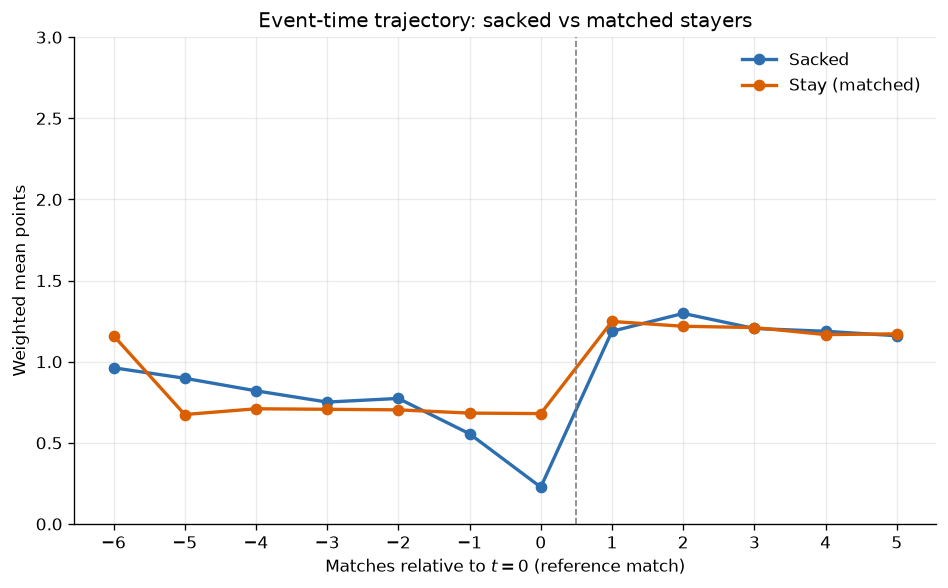

group,Sacked,Stay (matched)
t,,
-6,0.963,1.161
-5,0.898,0.675
-4,0.821,0.710
-3,0.751,0.707
-2,0.774,0.703
-1,0.556,0.683
0,0.227,0.680
1,1.188,1.248
2,1.298,1.219


In [31]:
units = matched[
    ["league", "season", "club", "date", "matchweek", "treated", "w"]
].rename(columns={"date": "t0_date", "matchweek": "t0_matchweek"})
units["unit_id"] = np.arange(len(units))

traj_m = panel.merge(
    units[
        ["unit_id", "league", "season", "club", "t0_date", "t0_matchweek", "treated", "w"]
    ],
    on=["league", "season", "club"],
    how="inner",
)

pre = traj_m.loc[traj_m["date"] <= traj_m["t0_date"]].copy()
pre["t"] = pre["matchweek"] - pre["t0_matchweek"]
pre = pre.loc[pre["t"].between(-6, 0)]

post = traj_m.loc[traj_m["date"] > traj_m["t0_date"]].copy()
post["t"] = post.groupby("unit_id")["date"].rank(method="first").astype(int)
post = post.loc[post["t"].between(1, 5)]

traj = pd.concat([pre, post], ignore_index=True)

summary = (
    traj.groupby(["treated", "t"], group_keys=False)
    .apply(
        lambda g: pd.Series(
            {
                "mean_ppg": np.average(g["points"], weights=g["w"]),
                "n": g["unit_id"].nunique(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)
summary["group"] = summary["treated"].map({1: "Sacked", 0: "Stay (matched)"})

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"Sacked": "#2c6eaf", "Stay (matched)": "#d95f02"}
for name, g in summary.groupby("group"):
    g = g.sort_values("t")
    ax.plot(
        g["t"],
        g["mean_ppg"],
        marker="o",
        label=name,
        color=colors[name],
        linewidth=2,
    )

ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(-6, 6))
ax.set_xlabel("Matches relative to $t=0$ (reference match)")
ax.set_ylabel("Weighted mean points")
ax.set_title("Event-time trajectory: sacked vs matched stayers")
ax.set_ylim(0, 3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

(
    summary.pivot(index="t", columns="group", values="mean_ppg")
    [["Sacked", "Stay (matched)"]]
    .round(3)
)


Before the sacking, the blue line crashes. That's the decline that gets a manager fired. The orange line (matched stayers) is low and relatively flat.

After $t=0$, both lines jump to roughly the same level and stay there. Sacked clubs go from about 0.23 PPG at $t=0$ to about 1.2. Matched stayers recover at nearly the same rate, from about 0.68 to about 1.2.

The bounce is real in the sense that results *do* improve after a sacking. But clubs in similar situations who kept their manager improved by roughly the same amount. The ATT of 0.004 confirms that **sacking the manager produces no measurable advantage over keeping him.**


## Robustness: three, five, and eight matches

Five matches is the primary window, but I want to make sure the result isn't sensitive to that choice. Here I re-run the same CEM matching for **three-match and eight-match** windows, only including clubs that have enough games remaining in the season. If the null result were just an artifact of the five-match cutoff, we'd expect to see a different picture at other horizons.


In [32]:
def matched_att(outcome: str, require: str) -> dict:
    t = t0.loc[t0[require]].copy()
    c = panel.loc[
        ~panel["row_id"].isin(treated_ids)
        & ~panel["row_id"].isin(near_ids)
        & panel[require]
        & (panel["trailing_matches"] >= 6)
        & (panel["matchweek"] > 1)
    ].copy()
    c["treated"] = 0

    pool_w = pd.concat([add_bins(t), add_bins(c)], ignore_index=True)
    cts = pool_w.groupby("stratum")["treated"].agg(n_t="sum", n="size")
    cts["n_c"] = cts["n"] - cts["n_t"]
    keep_w = cts.query("n_t >= 1 and n_c >= 1").index
    m = pool_w.loc[pool_w["stratum"].isin(keep_w)].copy()

    nt = m.groupby("stratum")["treated"].transform("sum")
    nc = m.groupby("stratum")["treated"].transform(lambda s: (1 - s).sum())
    m["w"] = 1.0
    m.loc[m["treated"] == 0, "w"] = nt[m["treated"] == 0] / nc[m["treated"] == 0]

    yy1 = m.loc[m["treated"] == 1, outcome].mean()
    ww0 = m.loc[m["treated"] == 0, "w"]
    yy0 = (ww0 * m.loc[m["treated"] == 0, outcome]).sum() / ww0.sum()
    a = yy1 - yy0
    nn = int(m["treated"].sum())
    ss1 = m.loc[m["treated"] == 1, outcome].std(ddof=1)
    ss0 = m.loc[m["treated"] == 0, outcome].std(ddof=1)
    sse = np.sqrt(ss1**2 / nn + ss0**2 / nn)
    return {
        "Window": outcome.replace("ppg_next_", "Next "),
        "N sacked": nn,
        "Sacked PPG": yy1,
        "Stay PPG": yy0,
        "ATT": a,
        "SE": sse,
        "95% CI": f"[{a - 1.96 * sse:.3f}, {a + 1.96 * sse:.3f}]",
    }


robust = pd.DataFrame(
    [
        matched_att("ppg_next_3", "has_next_3"),
        matched_att("ppg_next_5", "has_next_5"),
        matched_att("ppg_next_8", "has_next_8"),
    ]
).set_index("Window")
robust.round(3)


,N sacked,Sacked PPG,Stay PPG,ATT,SE,95% CI
Window,,,,,,
Next 3,582,1.231,1.223,0.009,0.045,"[-0.080, 0.097]"
Next 5,581,1.208,1.203,0.004,0.038,"[-0.070, 0.079]"
Next 8,539,1.181,1.184,-0.003,0.033,"[-0.067, 0.061]"


The ATT stays a rounding error from zero at three, five, and eight matches. Five matches then is an appropriate choice.

## Wrapping up

I'm far from the first person to look into this. The new manager bounce has been studied in sports economics for years. Ter Weel (2011) found no clear performance gain from managerial turnover in Dutch football. De Paola and Scoppa (2012) reached a similar conclusion for Serie A. Van Ours and van Tuijl (2016) made the regression-to-the-mean point most clearly: results improve after a sacking, but they also improve for clubs that had a similar bad run and kept their manager. Bryson et al. (2024) looked across four countries and again found little short-run benefit once you build a proper comparison group. My results are in line with all of this.

I wanted to do it myself because (1) it's a fun dataset, (2) I wanted to practice causal inference on something I actually care about, and (3) I hadn't seen this question tackled with CEM specifically. Most of these papers use difference-in-differences, nearest-neighbor matching, or entropy balancing. CEM is in the same family but it handles the **positivity requirement** more directly: if a sacking has no comparable unsacked club in its bin, it drops out entirely instead of getting a fuzzy propensity weight.

The result: **sacking your manager doesn't help in the next five games, and it doesn't hurt either.** The bounce in the raw data is almost entirely regression to the mean. Clubs that kept their manager through a similar rough patch recovered at the same rate. Matched next-five PPG is about 1.21 whether you sacked or stayed. The ATT is roughly zero.

That said, there's more to dig into:

1. **Was the slump a surprise?** The main threat to this design is that boards fire after bad results *relative to expectations*, not just after bad absolute form. Matching on trailing PPG alone may still mix "we were supposed to be 18th" with "we were supposed to be 6th." Some studies utlize bookmaker odds and fold that into expected points (à la Van Ours and van Tuijl).
2. **Heterogeneity.** Does a sacking do anything different in the bottom six versus mid-table? The **ATT** tells us the average effect across all sackings, but it's possible that sacking helps relegation-threatened clubs while doing nothing for mid-table ones, or vice versa. In causal inference this is called the conditional average treatment effect (**CATE**) — the treatment effect for a specific subgroup.
3. **Longer horizons.** A longer horizon (say a twenty-game window) would answer a different question ("does the hire eventually matter?") and would need care about clubs that sack again mid-window.

If time permits, I'll be working on a part 2. Cheers!

### References

- Bryson, A., Buraimo, B., Farnell, A., & Simmons, R. (2024). Special ones? The effect of head coaches on football team performance. *Scottish Journal of Political Economy*.
- De Paola, M., & Scoppa, V. (2012). The effects of managerial turnover. *Journal of Sports Economics*.
- Facure Alves, M. (2021). Causal Inference for the Brave and True. https://matheusfacure.github.io/python-causality-handbook/landing-page.html
- Ter Weel, B. (2011). Does manager turnover improve firm performance? Evidence from Dutch soccer, 1986–2004. *De Economist*.
- van Ours, J. C., & van Tuijl, M. A. (2016). In-season head-coach dismissals and the performance of professional football teams. *Economic Inquiry*.
